text

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
import os

sys.path.append(os.path.abspath('Python Version'))

# Now Python will successfully find your scripts!
from data_cleansing import *
from feature_engineering import *
from dimensionality_reduction import *
from EDA import *
from hypothesis_testing import *

# Load the dataset
file_path = '../Project_Datasets/flights_sample_3m.csv'
df = pd.read_csv(file_path)

# Print the initial shape to show the RAW data size
print("Initial dataset shape before cleansing (rows, columns):", df.shape)

# Run data cleansing
df = run_data_cleansing_pipeline(df)

output_filename = '../Project_Datasets/cleansed_flights_data.csv'
df.to_csv(output_filename, index=False)

# Print the initial shape to show the RAW data size
print("\nDataset shape after cleansing (rows, columns):", df.shape)

#Run feature engineering
df = run_feature_engineering_pipeline(df)

output_filename = '../Project_Datasets/engineered_flights_data.csv'
df.to_csv(output_filename, index=False)

Initial dataset shape before cleansing (rows, columns): (11364, 32)

Dataset shape after cleansing (rows, columns): (11058, 11)


text

In [2]:
# Show the size of the data after cleansing
print("Cleaned Dataset Shape:", df.shape)

# 1. Check statistics for Base Features
print("\n--- Data Cleansing Results ---")
base_features = ['DISTANCE', 'CRS_ELAPSED_TIME', 'ARR_DELAY']
run_descriptive_statistics(df, base_features, "descriptive_statistics_base_features.csv")

# 2. Check statistics for Engineered Features
print("\n--- Feature Engineering Results ---")
new_masterpiece_features = [
    'SCHEDULED_SPEED',
    'ORIGIN_CONGESTION',
    'DESTINATION_CONGESTION',
    'ROUTE_BOTTLENECK_INTERACTION',
    'AIRLINE_HUB_DOMINANCE',
    'ROUTE_FREQUENCY',
]
run_descriptive_statistics(df, new_masterpiece_features, "descriptive_statistics_engineered_features.csv")

Cleaned Dataset Shape: (11058, 22)

--- Data Cleansing Results ---

--- DESCRIPTIVE STATISTICS & DATA OVERVIEW ---

Basic Summary Statistics:
       DISTANCE  CRS_ELAPSED_TIME  ARR_DELAY
count  11058.00          11058.00   11058.00
mean     808.14            142.22       3.77
std      585.21             71.21      49.00
min       31.00             28.00     -62.00
25%      383.00             90.00     -15.00
50%      651.00            125.00      -7.00
75%     1044.75            173.00       6.00
max     5095.00            665.00    1185.00

Variance:
DISTANCE            342475.53
CRS_ELAPSED_TIME      5071.20
ARR_DELAY             2401.16
dtype: float64

Skewness:
DISTANCE            1.56
CRS_ELAPSED_TIME    1.49
ARR_DELAY           9.63
dtype: float64

Kurtosis:
DISTANCE              3.32
CRS_ELAPSED_TIME      3.02
ARR_DELAY           160.37
dtype: float64

--- Feature Engineering Results ---

--- DESCRIPTIVE STATISTICS & DATA OVERVIEW ---

Basic Summary Statistics:
       SCHEDULED_

text

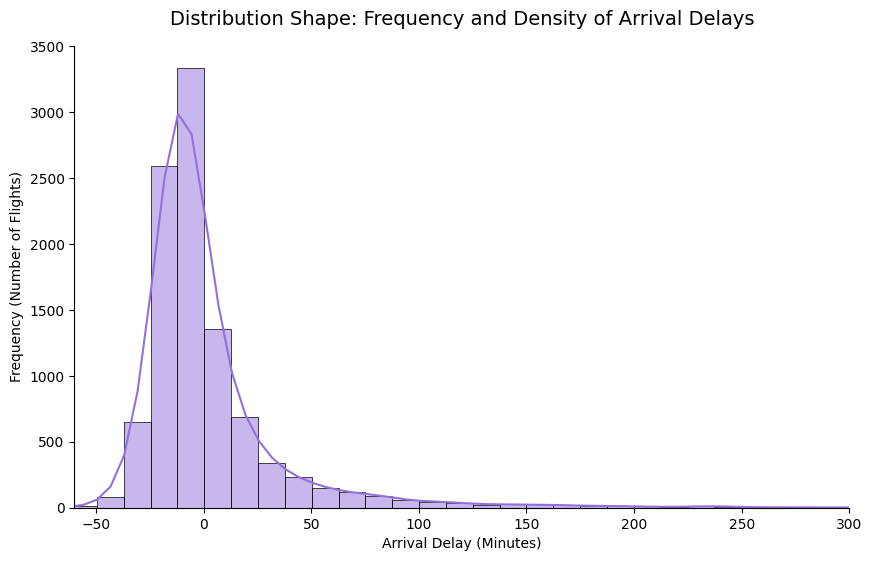

In [3]:
# Create a simple random sample of 10,000 records for faster, cleaner plotting [1]
df_sample = df.sample(n=10000, random_state=42)

# Generate the plot for Theme 1
plot_delay_distribution(df_sample)

text

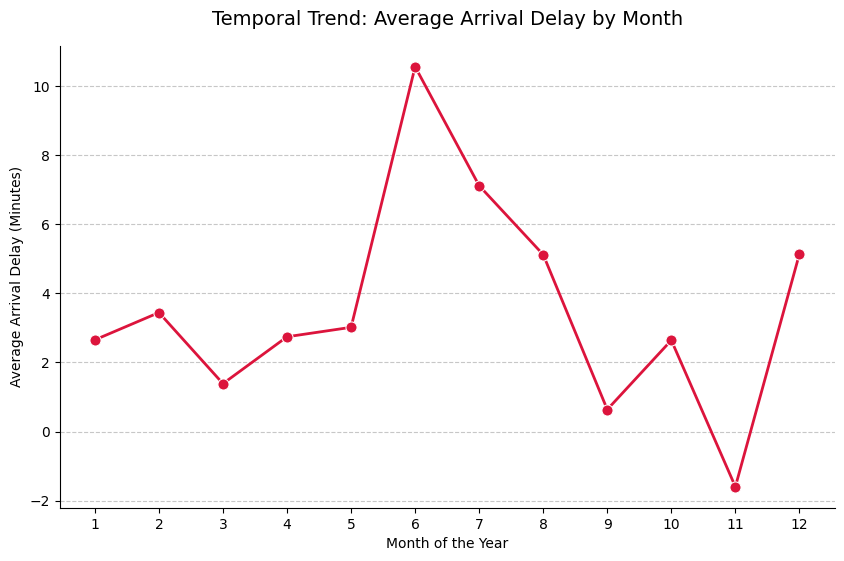

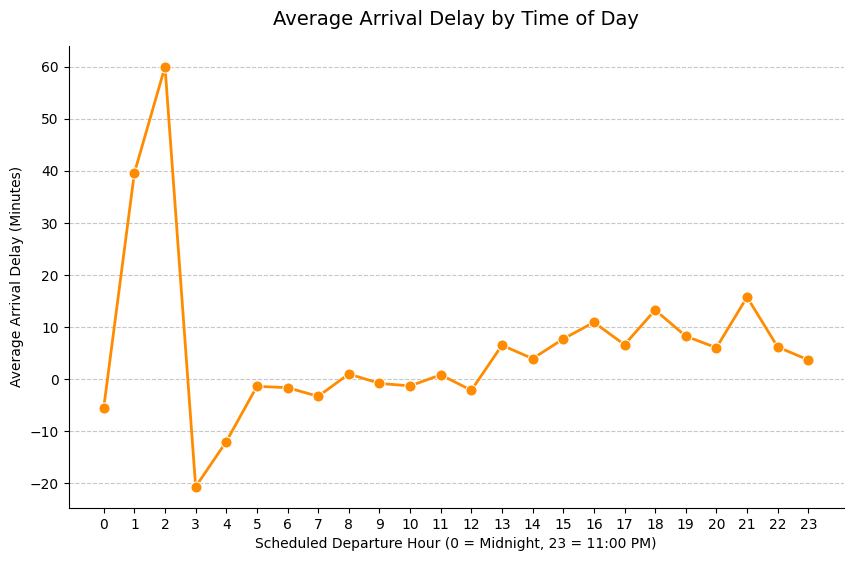

In [4]:
# Recreate DEP_HOUR temporarily
if 'MONTH' not in df.columns: 
    df['MONTH'] = df['FL_DATE'].astype(str).str[5:7].astype(int)
    
if 'DEP_HOUR' not in df.columns: 
    df['DEP_HOUR'] = df['CRS_DEP_TIME'] // 100
    
# Call the Generalized Line Chart for MONTHS
plot_temporal_delay_trend(
    df=df,
    time_col='MONTH',
    title='Temporal Trend: Average Arrival Delay by Month',
    xlabel='Month of the Year',
    xticks_range=range(1, 13),
    line_color='crimson'
)

# Call the Generalized Line Chart for HOURS
plot_temporal_delay_trend(
    df=df,
    time_col='DEP_HOUR',
    title='Average Arrival Delay by Time of Day',
    xlabel='Scheduled Departure Hour (0 = Midnight, 23 = 11:00 PM)',
    xticks_range=range(0, 24),
    line_color='darkorange'
)

text

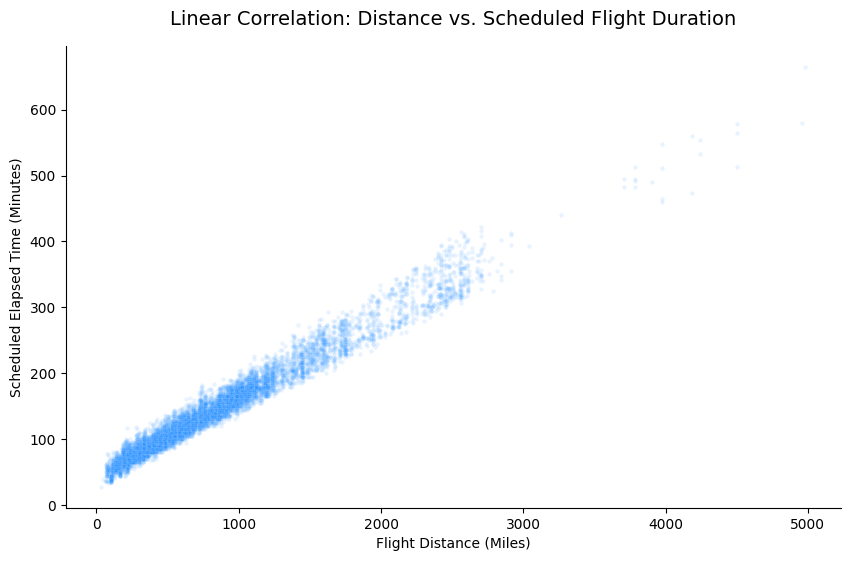

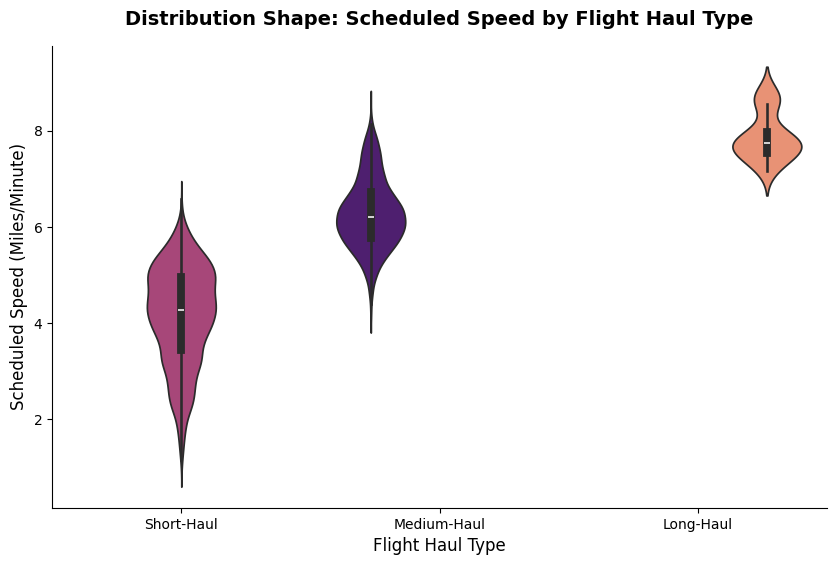

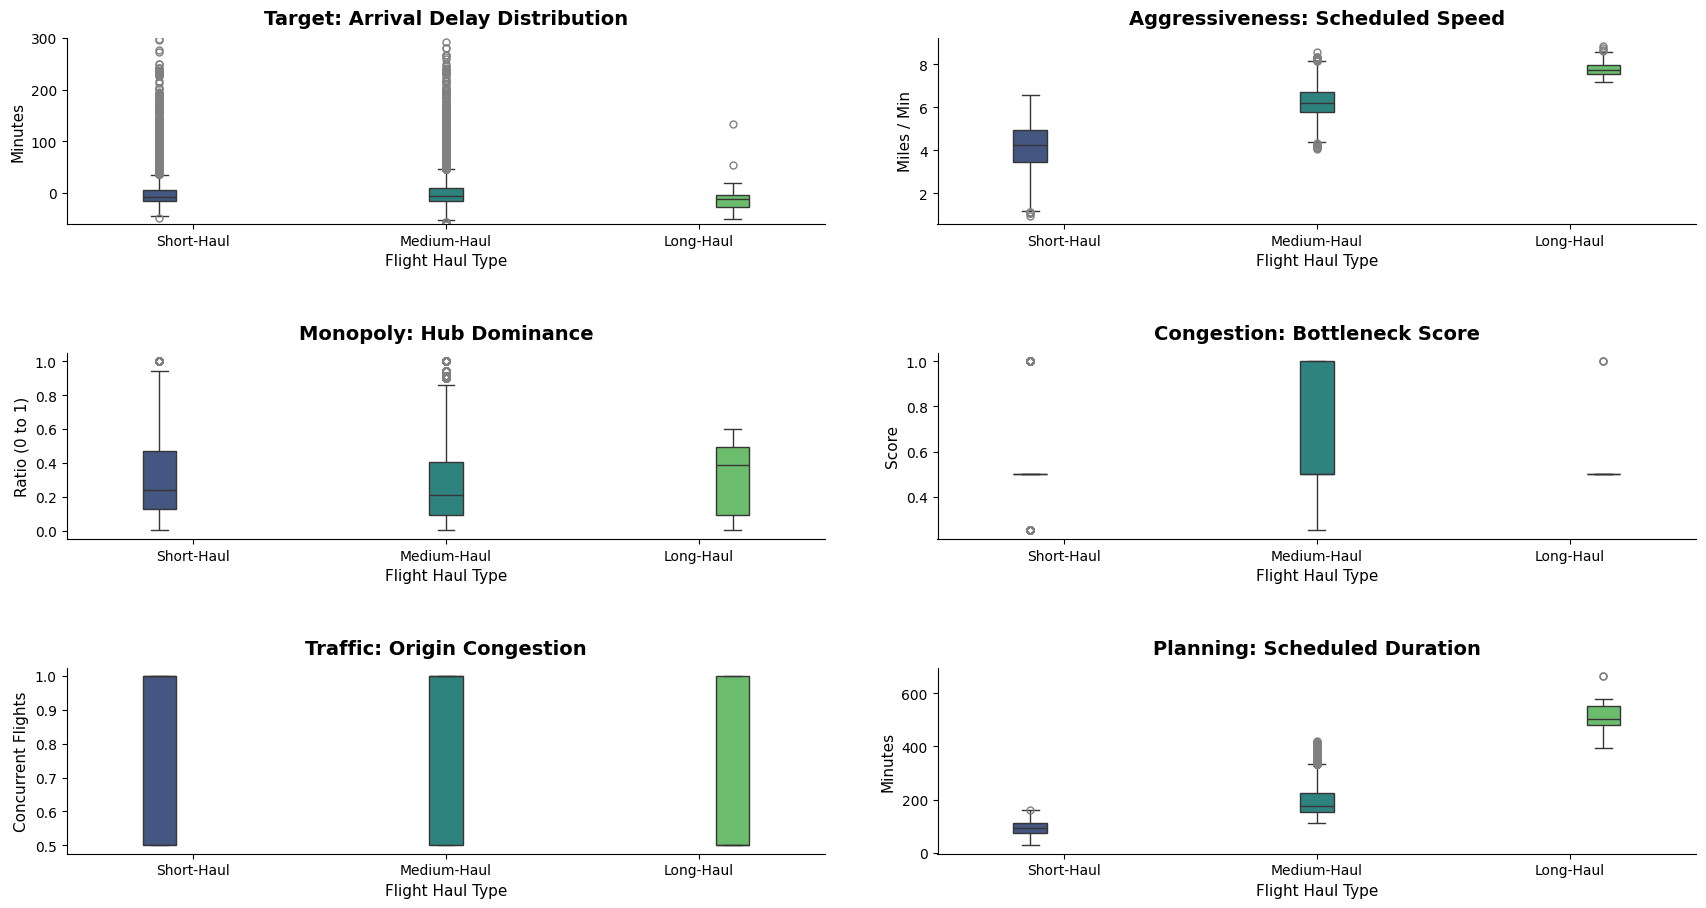

In [5]:
# Generate the scatter plot for Distance vs Duration
plot_distance_vs_duration(df_sample)

# Generate the violin plot and boxplots for Flight Haul Types [2, 3]
plot_speed_violin_distribution(df)
plot_categorical_boxplots(df)

text

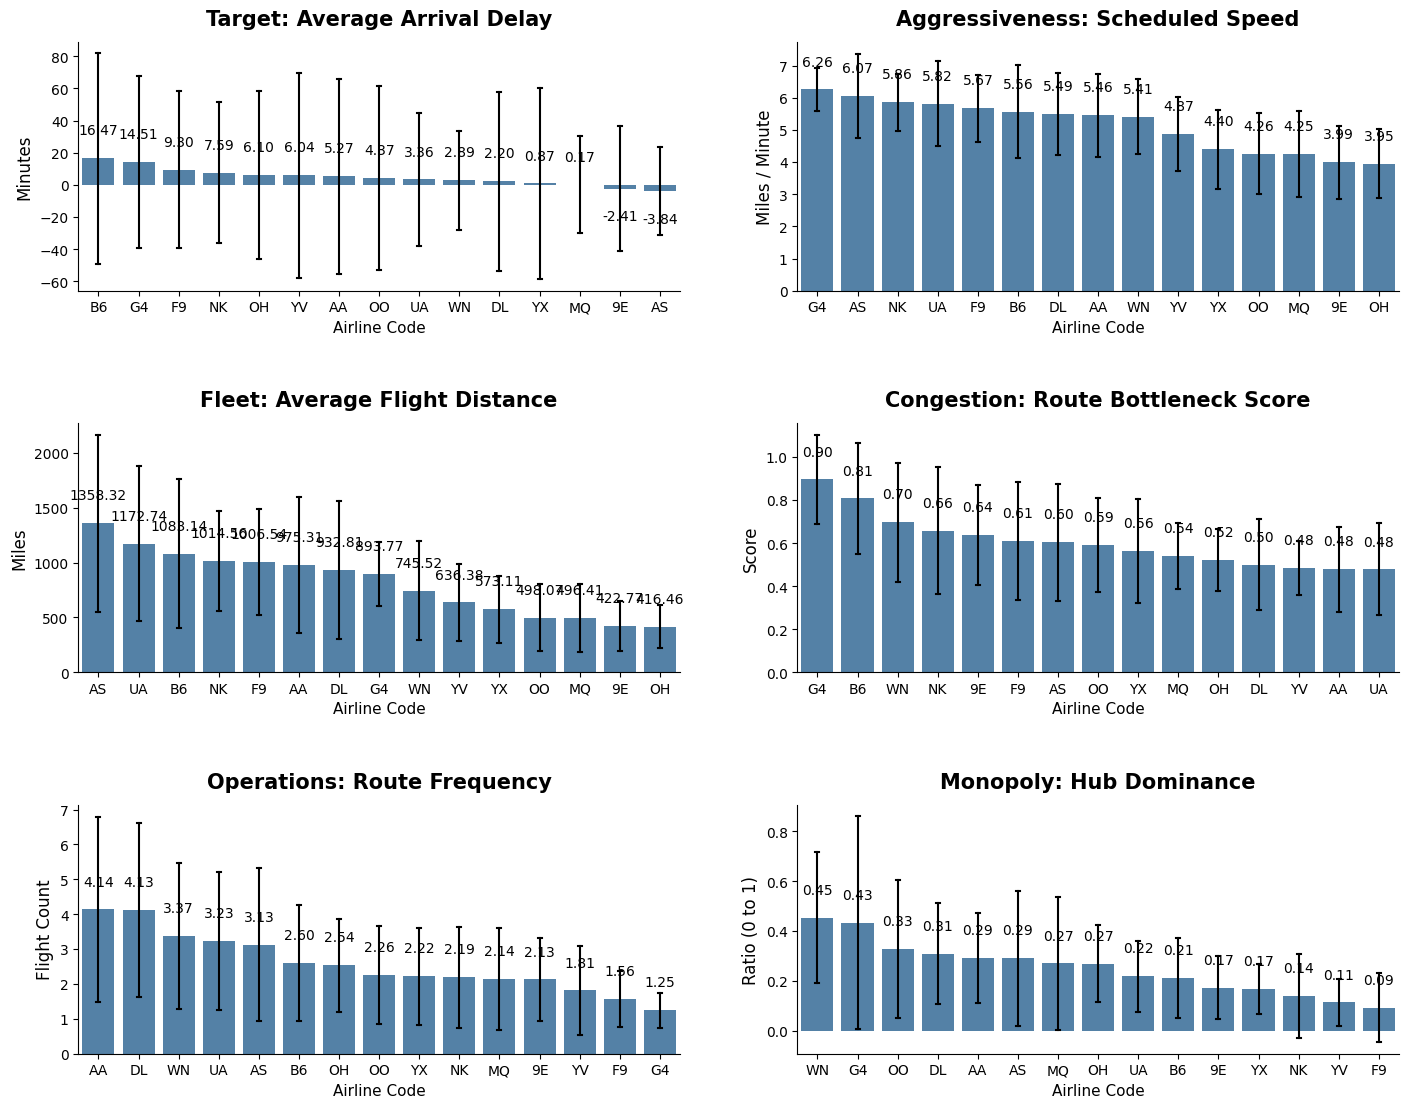

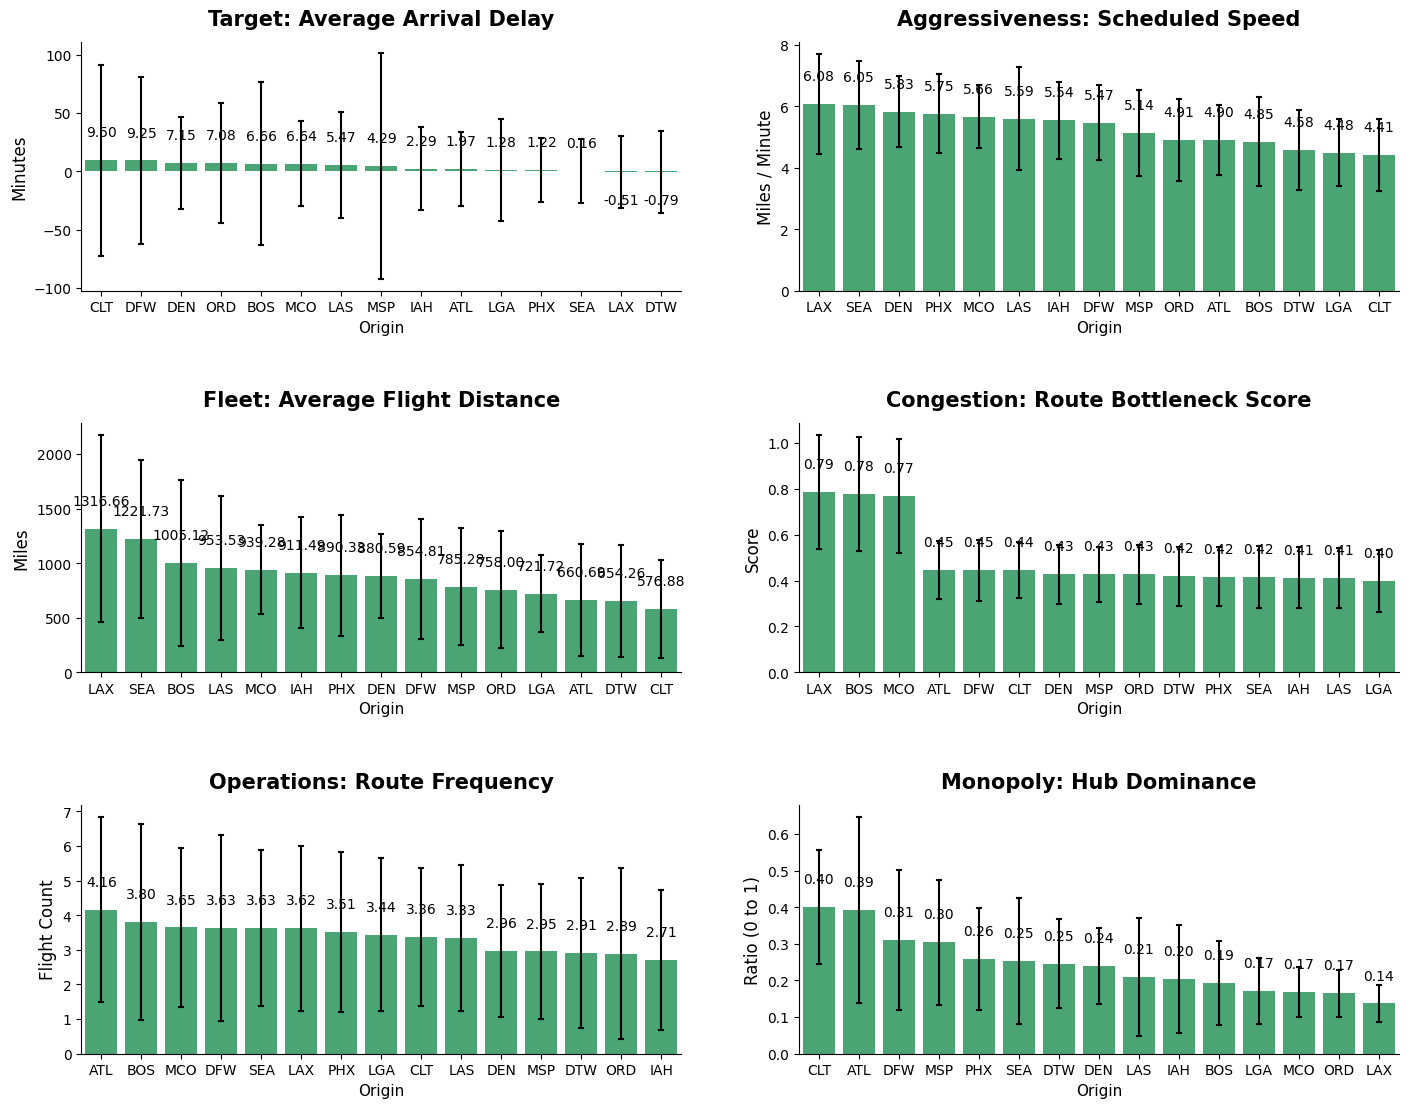

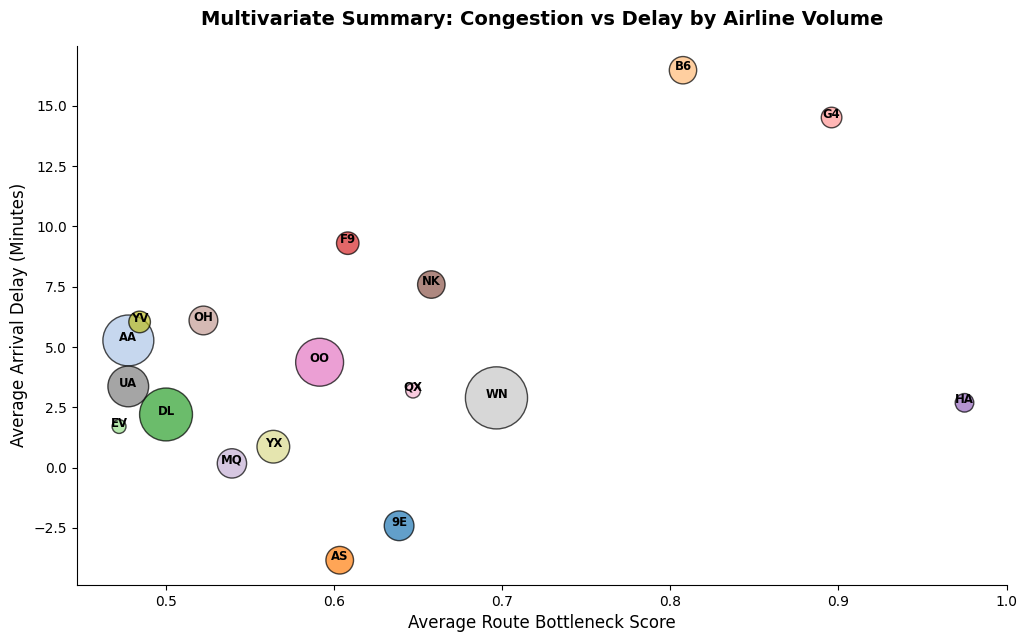

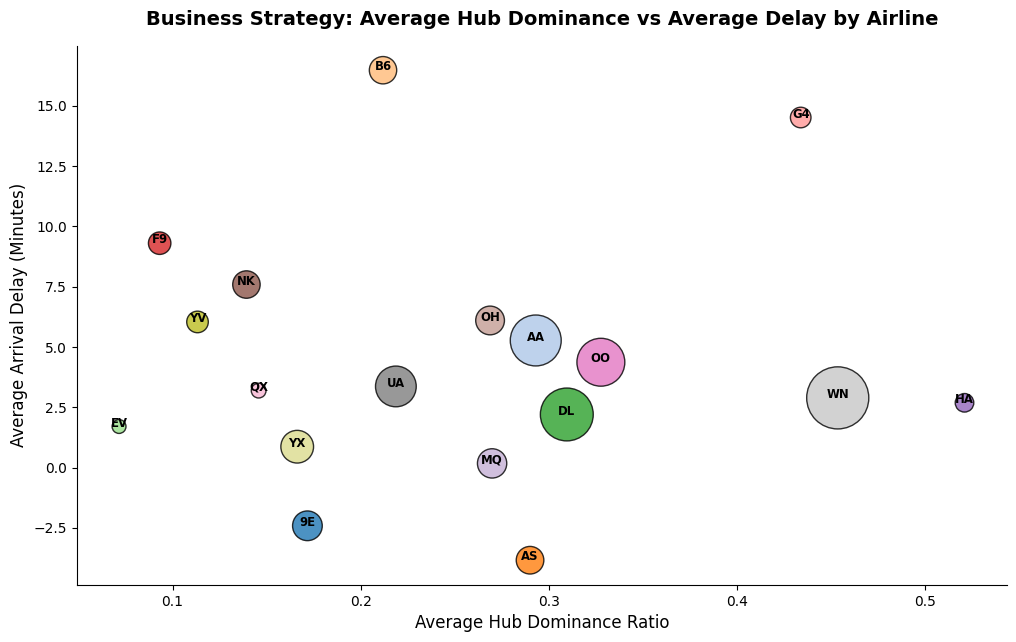

ValueError: Cannot take a larger sample than population when 'replace=False'

In [6]:
# Executive profiles for Airlines and Origins [2]
plot_executive_profile(df, categorical_col='AIRLINE_CODE', plot_color='steelblue') 
plot_executive_profile(df, categorical_col='ORIGIN', top_n=15, plot_color='mediumseagreen')

# Generate the Bubble Chart and Congestion Grid [3]
plot_executive_bubble_chart(df)
plot_dominance_bubble(df)
plot_congestion_vs_delay_grid(df)

text

In [ ]:
# Show the overlapping scatter plots for redundancy visualization [3]
plot_frequency_vs_delay(df)

text

In [ ]:
iso_features = ['DISTANCE', 'CRS_ELAPSED_TIME', 'SCHEDULED_SPEED']
df = remove_outliers_isolation_forest(df, iso_features, contamination=0.01)

output_filename = '../Project_Datasets/removed_outliers_data.csv'
df.to_csv(output_filename, index=False)

text

In [ ]:
# Run the entire dimensionality reduction pipeline (Scaling, PCA, and UMAP)
execute_dimensionality_reduction(df)

output_filename = '../Project_Datasets/scaled_data.csv'
df.to_csv(output_filename, index=False)

In [ ]:
# Recreate DEP_HOUR temporarily
if 'MONTH' not in df.columns: 
    df['MONTH'] = df['FL_DATE'].astype(str).str[5:7].astype(int)
    
if 'DEP_HOUR' not in df.columns: 
    df['DEP_HOUR'] = df['CRS_DEP_TIME'] // 100
    
# Hypothesis 1: Departure Time Effect
print("\nTest 1: Does the scheduled Time of Day (Departure Hour) significantly affect delays?")
perform_kruskal_wallis(df, group_col='DEP_HOUR', target_col='ARR_DELAY');

# Hypothesis 2: Month Effect
print("\nTest 2: Does the Month of the year significantly affect arrival delays?")
perform_kruskal_wallis(df, group_col='MONTH', target_col='ARR_DELAY');

text